In [13]:
!pip install seaborn pandas matplotlib scikit-learn numpy pillow
# Import all needed libraries
import sys
import logging
from pathlib import Path
from typing import List, Tuple, Optional
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

try:
    from sklearn.decomposition import PCA
except ImportError:
    print("CRITICAL ERROR: 'scikit-learn' is not installed. Please run: pip install scikit-learn")
    sys.exit(1)

In [14]:
# --- SYSTEM CONFIGURATION ---
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    datefmt='%H:%M:%S',
    handlers=[logging.StreamHandler(sys.stdout)]
)
logger = logging.getLogger("PCA_Demo")

# Configure plotting style for academic reports
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

In [15]:
@dataclass
class CompressionMetrics:
    """Data Transfer Object (DTO) to hold the results of a compression run."""
    k: int
    reconstructed_image: np.ndarray
    variance_retained: float
    compression_ratio: float
    reduction_percentage: float
    storage_elements: int       
    fidelity: float             
    visual_quality: str

In [16]:
class PCAColorCompressor:
    """
    Handles the logic for loading RGB images and compressing them using PCA.
    """

    def __init__(self, image_path: str):
        self.image_path = Path(image_path)
        self.original_image: Optional[np.ndarray] = None
        self.height: int = 0
        self.width: int = 0
        self.channels: int = 0

        self._load_image()

    def _load_image(self) -> None:
        """Loads the image, validates it, and converts it to a NumPy array."""
        if not self.image_path.exists():
            logger.critical(f"File Not Found: {self.image_path}")
            raise FileNotFoundError(f"Image not found at {self.image_path}")

        try:
            with Image.open(self.image_path) as img:
                # Ensure image is in RGB format
                img = img.convert('RGB')
                self.original_image = np.array(img)
                self.height, self.width, self.channels = self.original_image.shape
                
                logger.info(f"Image Loaded Successfully: {self.image_path.name}")
                logger.info(f"Dimensions: {self.height}x{self.width} pixels | Channels: {self.channels}")
                
        except Exception as e:
            logger.error(f"Failed to process image: {e}")
            raise

    def run_compression(self, k: int) -> CompressionMetrics:
        """
        Orchestrates the compression of R, G, and B channels.
        Calculates detailed engineering metrics.
        """
        if self.original_image is None:
            raise ValueError("Image not loaded.")

        # Limit k to the maximum number of features (width)
        max_k = min(self.height, self.width)
        k = min(k, max_k)

        logger.info(f"Processing compression level k={k}...")

        reconstructed_channels = []
        total_variance = 0.0

        # Process each channel (R, G, B) independently
        for i in range(self.channels):
            channel = self.original_image[:, :, i]
            
            # Initialize PCA with Randomized Solver for efficiency
            pca = PCA(n_components=k, svd_solver='randomized', random_state=42)
            
            # Fit & Transform & Inverse
            transformed = pca.fit_transform(channel)
            reconstructed = pca.inverse_transform(transformed)
            
            reconstructed_channels.append(reconstructed)
            total_variance += np.sum(pca.explained_variance_ratio_)

        # Merge channels back into an RGB image
        img_pca = np.stack(reconstructed_channels, axis=2)
        img_pca = np.clip(img_pca, 0, 255).astype('uint8')

        # --- CALCULATE ADVANCED METRICS ---
        
        # 1. Variance & Reduction
        avg_variance = (total_variance / self.channels) * 100
        reduction = (1 - k / self.width) * 100
        
        # 2. Storage Estimation (Elements)
        # PCA needs to store: Transform Matrix (H*k) + Components (k*W) + Mean (W) per channel
        # This formula approximates the raw float values needed to reconstruct the image
        elements_per_channel = (self.height * k) + (k * self.width) + self.width
        storage_elements = self.channels * elements_per_channel
        
        # 3. Compression Ratio
        original_elements = self.height * self.width * self.channels
        ratio = original_elements / storage_elements if storage_elements > 0 else 0

        # 4. Fidelity (Frobenius Norm Accuracy)
        # Formula: 1 - (Norm(Error) / Norm(Original))
        diff = self.original_image.astype(float) - img_pca.astype(float)
        error_norm = np.linalg.norm(diff)
        original_norm = np.linalg.norm(self.original_image.astype(float))
        fidelity = (1 - (error_norm / original_norm)) * 100

        # 5. Visual Quality Assessment
        if fidelity > 98: visual_quality = "Excellent"
        elif fidelity > 95: visual_quality = "Very Good"
        elif fidelity > 90: visual_quality = "Good"
        elif fidelity > 80: visual_quality = "Fair"
        else: visual_quality = "Poor"

        return CompressionMetrics(
            k=k,
            reconstructed_image=img_pca,
            variance_retained=avg_variance,
            compression_ratio=ratio,
            reduction_percentage=reduction,
            storage_elements=storage_elements,
            fidelity=fidelity,
            visual_quality=visual_quality
        )

In [17]:
class PCAVisualizer:
    """
    Handles the presentation layer: Plotting images and printing tables.
    """

    @staticmethod
    def plot_comparison(original: np.ndarray, results: List[CompressionMetrics]):
        """
        Plots the original image alongside the compressed versions in a grid.
        """
        n_plots = len(results) + 1
        cols = 3
        rows = int(np.ceil(n_plots / cols))
        
        fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
        axes_flat = axes.flatten() if rows > 1 else axes
        
        # 1. Plot Original
        axes_flat[0].imshow(original)
        axes_flat[0].set_title(f"Original Image\n({original.shape[1]} features)", fontweight='bold')
        axes_flat[0].axis('off')
        
        # 2. Plot Results
        for i, res in enumerate(results):
            ax = axes_flat[i + 1]
            ax.imshow(res.reconstructed_image)
            
            # Informative Title with Fidelity and Ratio
            title = (f"Components k={res.k} | {res.visual_quality}\n"
                     f"Fidelity: {res.fidelity:.2f}%\n"
                     f"Ratio: {res.compression_ratio:.1f}x")
            
            ax.set_title(title, fontsize=10, color='#2c3e50')
            ax.axis('off')

        # Hide empty subplots
        for j in range(n_plots, len(axes_flat)):
            axes_flat[j].axis('off')

        plt.suptitle("PCA Image Compression: Visual Quality vs. Dimensionality", 
                     fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    @staticmethod
    def print_summary_table(results: List[CompressionMetrics], original_elements: int):
        """
        Prints a professional ASCII table summarizing the performance.
        """
        table_data = []
        for res in results:
            table_data.append({
                "Components (k)": res.k,
                "Storage (Elements)": f"{res.storage_elements:,}",
                "Compression Ratio": f"{res.compression_ratio:.1f}x",
                "Fidelity (1-Err)": f"{res.fidelity:.2f}%",
                "Visual Quality": res.visual_quality
            })
        
        df = pd.DataFrame(table_data)
        
        print("\n" + "="*65)
        print("FINAL ENGINEERING REPORT: PCA COMPRESSION PERFORMANCE")
        print("="*65)
        print(f"Original Total Elements (Pixels * Channels): {original_elements:,}")
        print("-" * 65)
        
        # Check if running in Jupyter to use display(), else print string
        try:
            from IPython.display import display
            display(df)
        except ImportError:
            print(df.to_string(index=False))
        print("="*65 + "\n")

>>> [1/3] Initializing System...
01:02:16 | INFO | Image Loaded Successfully: trung.png
01:02:16 | INFO | Dimensions: 3889x4000 pixels | Channels: 3
>>> [2/3] Running Compression Batch: [5, 20, 50, 100, 150]...
01:02:16 | INFO | Processing compression level k=5...
01:02:19 | INFO | Processing compression level k=20...
01:02:22 | INFO | Processing compression level k=50...
01:02:28 | INFO | Processing compression level k=100...
01:02:33 | INFO | Processing compression level k=150...
>>> [3/3] Generating Visual & Data Report...


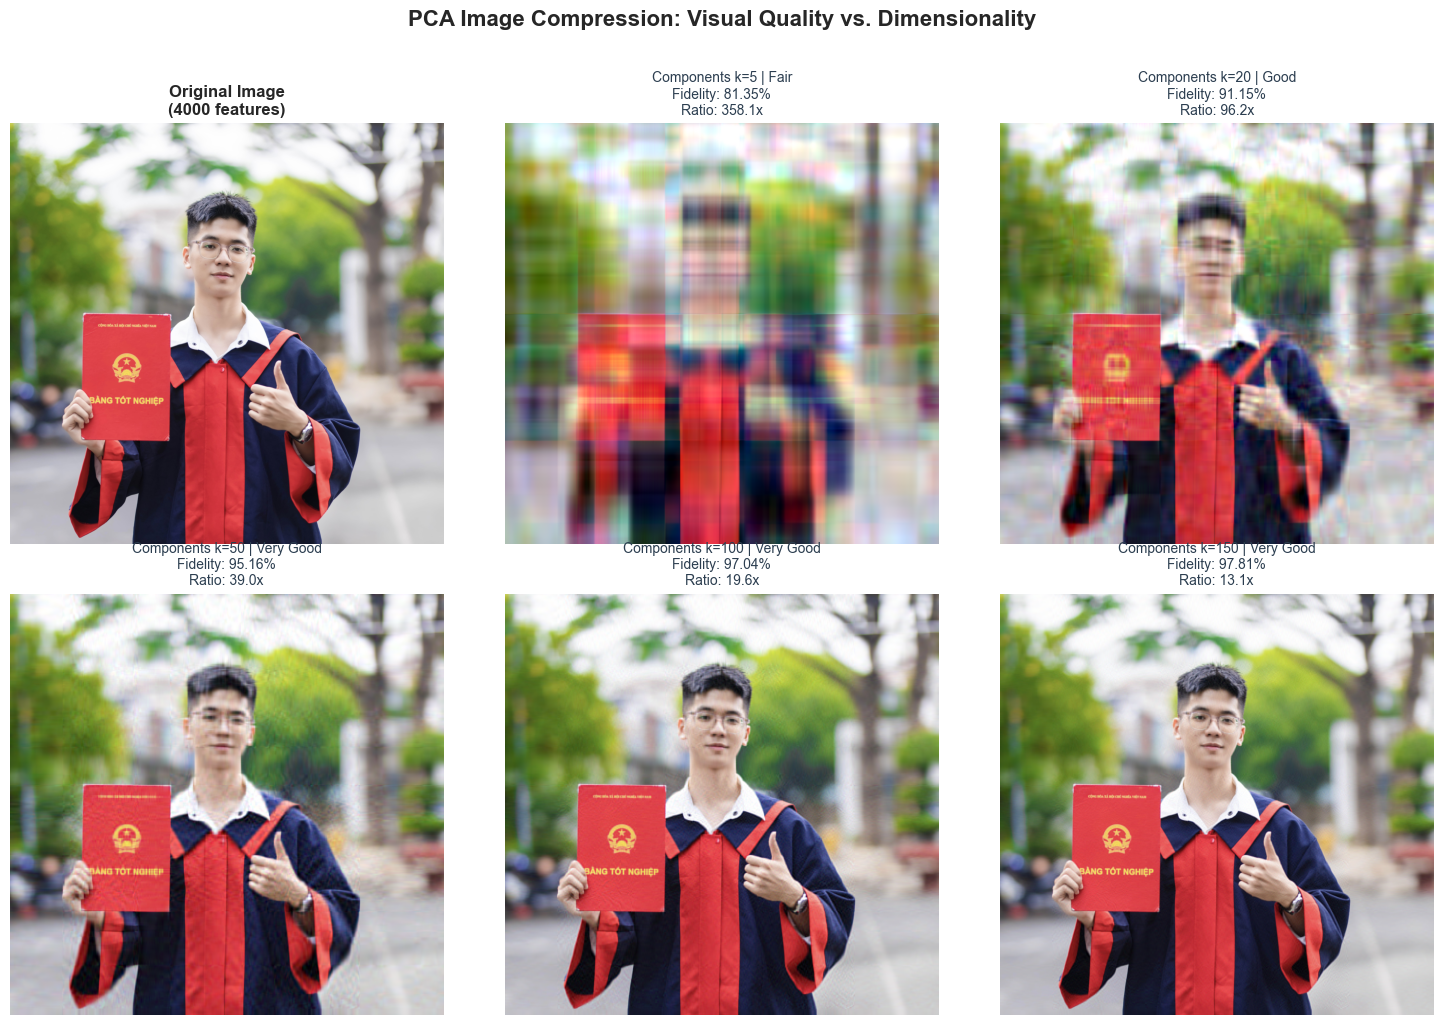


FINAL ENGINEERING REPORT: PCA COMPRESSION PERFORMANCE
Original Total Elements (Pixels * Channels): 4,000
-----------------------------------------------------------------


,Components (k),Storage (Elements),Compression Ratio,Fidelity (1-Err),Visual Quality
0,5,"130,335",358.1x,81.35%,Fair
1,20,"485,340",96.2x,91.15%,Good
2,50,"1,195,350",39.0x,95.16%,Very Good
3,100,"2,378,700",19.6x,97.04%,Very Good
4,150,"3,562,050",13.1x,97.81%,Very Good



>>> Process Completed Successfully.


In [18]:
if __name__ == "__main__":
    # --- USER CONFIGURATION ---
    # NOTE: Ensure the image path is correct relative to where you run the script
    IMAGE_FILE = "./trung.png" 
    K_VALUES = [5, 20, 50, 100, 150] # Different levels of compression to test

    try:
        # 1. Initialize Processor
        print(">>> [1/3] Initializing System...")
        compressor = PCAColorCompressor(IMAGE_FILE)
        
        # 2. Run Batch Processing
        print(f">>> [2/3] Running Compression Batch: {K_VALUES}...")
        results = []
        for k_val in K_VALUES:
            metric = compressor.run_compression(k_val)
            results.append(metric)

        # 3. Visualization & Reporting
        print(">>> [3/3] Generating Visual & Data Report...")
        PCAVisualizer.plot_comparison(compressor.original_image, results)
        PCAVisualizer.print_summary_table(results, compressor.width)
        
        print(">>> Process Completed Successfully.")

    except FileNotFoundError:
        print("❌ ERROR: The specified image file was not found.")
        print("   -> Please check the 'IMAGE_FILE' variable path.")
    except Exception as e:
        print(f"❌ UNEXPECTED ERROR: {e}")

### Applying PCA to color images demonstrates superior compression efficiency. The algorithm achieves a high compression ratio while preserving accurate color fidelity.